In [16]:
import torch
from torch import nn
from d2l import torch as d2l


In [17]:
# =============================================================================
# 1. 定义加性注意力机制 (Additive Attention)
# =============================================================================
# 作用：计算查询(Query)和键(Key)之间的相似度，并据此对值(Value)进行加权求和。
# 在Seq2Seq中，Query是解码器的隐藏状态，Key和Value都是编码器的输出。
class AdditiveAttention(nn.Module):
    """加性注意力"""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        # 将 Key 映射到隐藏层维度
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        # 将 Query 映射到隐藏层维度
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        # 将 tanh 后的特征映射到一个标量分数
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        """
        参数:
        queries: (batch_size, num_queries, query_size) - 解码器的隐藏状态
        keys: (batch_size, num_keys, key_size) - 编码器的输出
        values: (batch_size, num_keys, value_size) - 编码器的输出 (通常 keys == values)
        valid_lens: (batch_size,) 或 (batch_size, num_queries) - 有效长度，用于mask padding
        """
        # 1. 线性变换
        # queries: (batch_size, num_queries, num_hiddens)
        # keys: (batch_size, num_keys, num_hiddens)
        queries, keys = self.W_q(queries), self.W_k(keys)

        # 2. 维度扩展以便广播求和
        # queries.unsqueeze(2): (batch_size, num_queries, 1, num_hiddens)
        # keys.unsqueeze(1): (batch_size, 1, num_keys, num_hiddens)
        # 相加后 features: (batch_size, num_queries, num_keys, num_hiddens)
        # 这里实现了 W_q * q + W_k * k 的广播加法
        features = queries.unsqueeze(2) + keys.unsqueeze(1)

        # 3. 激活函数
        features = torch.tanh(features)

        # 4. 计算分数
        # self.w_v(features): (batch_size, num_queries, num_keys, 1)
        # squeeze(-1): (batch_size, num_queries, num_keys)
        scores = self.w_v(features).squeeze(-1)

        # 5. Masked Softmax
        # 将 padding 位置的分数设为极小值，使其 softmax 后概率为 0
        # self.attention_weights: (batch_size, num_queries, num_keys)
        self.attention_weights = d2l.masked_softmax(scores, valid_lens)

        # 6. 加权求和 (Context Vector)
        # bmm: (batch_size, num_queries, num_keys) * (batch_size, num_keys, value_size)
        # 结果: (batch_size, num_queries, value_size)
        return torch.bmm(self.dropout(self.attention_weights), values)


In [18]:
#@save
class AttentionDecoder(d2l.Decoder):
    """带有注意力机制解码器的基本接口"""
    def __init__(self, **kwargs):
        super(AttentionDecoder, self).__init__(**kwargs)

    @property
    def attention_weights(self):
        raise NotImplementedError


In [19]:
# =============================================================================
# 2. 定义带有注意力机制的 Seq2Seq 解码器
# =============================================================================
class Seq2SeqAttentionDecoder(AttentionDecoder):
    """
    带有注意力机制的 Seq2Seq 解码器
    """
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super(Seq2SeqAttentionDecoder, self).__init__(**kwargs)
        # 初始化注意力机制
        # key_size, query_size, num_hiddens 均设置为 num_hiddens
        # 因为 key 和 value 来自 encoder output (num_hiddens)
        # query 来自 decoder hidden state (num_hiddens)
        self.attention = AdditiveAttention(
            num_hiddens, num_hiddens, num_hiddens, dropout)

        # 嵌入层：将目标词汇索引映射为稠密向量
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # RNN 层：这里使用 GRU
        # 输入维度是 embed_size + num_hiddens，因为我们将 context vector 和 embedding 拼接作为输入
        self.rnn = nn.GRU(
            embed_size + num_hiddens, num_hiddens, num_layers,
            dropout=dropout)

        # 输出层：将 RNN 的隐藏状态映射回词汇表大小
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        """
        初始化解码器状态
        :param enc_outputs: 编码器的输出 (outputs, hidden_state)
        :param enc_valid_lens: 编码器输入的有效长度，用于 mask attention
        :return: (编码器输出(permuted), 编码器隐藏状态, 有效长度)
        """
        # outputs: (num_steps, batch_size, num_hiddens) - 包含所有时间步的隐藏状态
        # hidden_state: (num_layers, batch_size, num_hiddens) - 最后一个时间步的隐藏状态
        outputs, hidden_state = enc_outputs

        # 将 outputs 的形状从 (num_steps, batch_size, num_hiddens)
        # 转换为 (batch_size, num_steps, num_hiddens)
        # 这样做是为了方便后续进行 batch-wise 的 attention 计算 (batch_first=True)
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)

    def forward(self, X, state):
        """
        前向传播
        :param X: 解码器输入，形状 (batch_size, num_steps) - 目标序列的索引
        :param state: 解码器状态，包含 (enc_outputs, hidden_state, enc_valid_lens)
        :return: outputs, state
        """
        # 1. 解包状态
        # enc_outputs: (batch_size, num_steps, num_hiddens) - 用于 Attention 的 Key 和 Value
        # hidden_state: (num_layers, batch_size, num_hiddens) - 解码器当前的隐藏状态
        # enc_valid_lens: (batch_size,) - 有效长度
        enc_outputs, hidden_state, enc_valid_lens = state

        # 2. 嵌入层处理
        # X: (batch_size, num_steps) -> (batch_size, num_steps, embed_size)
        # permute(1, 0, 2) -> (num_steps, batch_size, embed_size) - 转换为 time-major 格式方便遍历
        X = self.embedding(X).permute(1, 0, 2)

        outputs, self._attention_weights = [], []

        # 3. 逐时间步进行解码
        for x in X:
            # x: (batch_size, embed_size) - 当前时间步的输入词向量

            # 4. 准备 Query
            # 使用解码器上一时间步的最后一层隐藏状态作为 Query
            # hidden_state[-1]: (batch_size, num_hiddens)
            # unsqueeze(1) -> (batch_size, 1, num_hiddens) - 增加维度以匹配 Attention 输入要求
            query = torch.unsqueeze(hidden_state[-1], dim=1)

            # 5. 计算 Context Vector (上下文向量)
            # self.attention 返回加权后的 enc_outputs
            # context: (batch_size, 1, num_hiddens)
            context = self.attention(
                query, enc_outputs, enc_outputs, enc_valid_lens)

            # 6. 拼接 Context Vector 和 输入词向量
            # torch.unsqueeze(x, dim=1): (batch_size, 1, embed_size)
            # cat -> (batch_size, 1, embed_size + num_hiddens)
            # 这意味着解码器不仅看到当前输入的词，还看到了通过 Attention 聚焦的源句子信息
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)

            # 7. RNN 前向传播
            # x.permute(1, 0, 2): (1, batch_size, embed_size + num_hiddens) - 转换为 time-major
            # out: (1, batch_size, num_hiddens) - 当前时间步的输出
            # hidden_state: (num_layers, batch_size, num_hiddens) - 更新后的隐藏状态
            out, hidden_state = self.rnn(x.permute(1, 0, 2), hidden_state)

            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)

        # 8. 全连接层变换 (输出层)
        # torch.cat(outputs, dim=0): (num_steps, batch_size, num_hiddens)
        # self.dense -> (num_steps, batch_size, vocab_size)
        outputs = self.dense(torch.cat(outputs, dim=0))

        # 9. 返回结果
        # outputs.permute(1, 0, 2): (batch_size, num_steps, vocab_size) - 转换回 batch-major
        # state: 更新后的状态列表
        return outputs.permute(1, 0, 2), [enc_outputs, hidden_state,
                                          enc_valid_lens]

    @property
    def attention_weights(self):
        return self._attention_weights


In [20]:
# 测试代码
# 创建一个简单的编码器
encoder = d2l.Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16,
                             num_layers=2)
encoder.eval()
# 创建带有注意力的解码器
decoder = Seq2SeqAttentionDecoder(vocab_size=10, embed_size=8, num_hiddens=16,
                                  num_layers=2)
decoder.eval()

# 模拟输入
X = torch.zeros((4, 7), dtype=torch.long)  # (batch_size, num_steps)
# 初始化解码器状态
state = decoder.init_state(encoder(X), None)
# 前向传播
output, state = decoder(X, state)

# 检查输出形状
# output: (batch_size, num_steps, vocab_size) -> (4, 7, 10)
# state[0]: enc_outputs -> (4, 7, 16)
# state[1]: hidden_state -> (2, 4, 16)
print(f"Output shape: {output.shape}")
print(f"State length: {len(state)}")
print(f"Encoder outputs shape: {state[0].shape}")
print(f"Hidden state shape: {state[1].shape}")


Output shape: torch.Size([4, 7, 10])
State length: 3
Encoder outputs shape: torch.Size([4, 7, 16])
Hidden state shape: torch.Size([2, 4, 16])


In [21]:
# =============================================================================
# 3. 显式定义 EncoderDecoder 类
# =============================================================================
class EncoderDecoder(nn.Module):
    """编码器-解码器架构的基类"""
    def __init__(self, encoder, decoder, **kwargs):
        super(EncoderDecoder, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, *args):
        # 1. 编码器处理源序列
        enc_outputs = self.encoder(enc_X, *args)
        # 2. 初始化解码器状态 (传入编码器输出)
        dec_state = self.decoder.init_state(enc_outputs, *args)
        # 3. 解码器处理目标序列 (返回预测结果)
        return self.decoder(dec_X, dec_state)

# =============================================================================
# 4. 显式定义训练函数
# =============================================================================
def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """训练序列到序列模型"""
    # 权重初始化函数
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])

    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    # 损失函数：不进行 reduction，以便后续使用 mask
    loss = nn.CrossEntropyLoss(reduction="none")
    net.train()
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                     xlim=[10, num_epochs])

    for epoch in range(num_epochs):
        timer = d2l.Timer()
        metric = d2l.Accumulator(2)  # 训练损失总和，词元数量

        for batch in data_iter:
            optimizer.zero_grad()
            # X: 源序列, X_valid_len: 源序列有效长度
            # Y: 目标序列, Y_valid_len: 目标序列有效长度
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]

            # 构造解码器输入 (Teacher Forcing)
            # 在每个目标序列前加上 <bos> (Beginning of Sentence)
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                          device=device).reshape(-1, 1)
            # dec_input: (batch_size, num_steps)
            # 移除 Y 的最后一个词，加上 <bos>，保持长度不变
            dec_input = torch.cat([bos, Y[:, :-1]], 1)

            # 前向传播
            # Y_hat: (batch_size, num_steps, vocab_size)
            Y_hat, _ = net(X, dec_input, X_valid_len)

            # 计算损失
            # loss 期望输入: (batch_size, vocab_size, num_steps) -> 需要 permute
            # loss 期望目标: (batch_size, num_steps)
            l = loss(Y_hat.permute(0, 2, 1), Y)

            # Masked Loss: 将 padding 位置的损失置为 0
            l = d2l.sequence_mask(l, Y_valid_len, value=0)

            # 反向传播
            l.sum().backward()

            # 梯度裁剪: 防止梯度爆炸
            d2l.grad_clipping(net, 1)

            num_tokens = Y_valid_len.sum()
            optimizer.step()

            with torch.no_grad():
                metric.add(l.sum(), num_tokens)

        if (epoch + 1) % 10 == 0:
            animator.add(epoch + 1, (metric[0] / metric[1],))

    print(f'loss {metric[0] / metric[1]:.3f}, {metric[1] / timer.stop():.1f} '
          f'tokens/sec on {str(device)}')


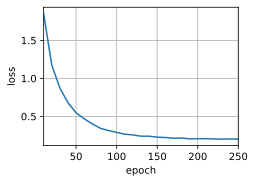

In [22]:
# 训练设置
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs, device = 0.005, 250, d2l.try_gpu()

# 加载机器翻译数据集
train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)

# 实例化编码器和解码器
encoder = d2l.Seq2SeqEncoder(
    len(src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqAttentionDecoder(
    len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)

# 使用我们自定义的 EncoderDecoder
net = EncoderDecoder(encoder, decoder)

# 使用我们自定义的 train_seq2seq
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)


In [23]:
# 预测和评估
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']

for eng, fra in zip(engs, fras):
    # 预测翻译结果和注意力权重
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    print(f'{eng} => {translation}, ',
          f'bleu {d2l.bleu(translation, fra, k=2):.3f}')


go . => va !,  bleu 1.000
i lost . => j'ai perdu .,  bleu 1.000
he's calm . => j'ai froid .,  bleu 0.000
i'm home . => je suis chez moi .,  bleu 1.000


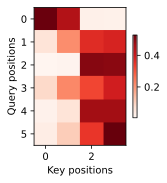

In [24]:
# 可视化注意力权重
# 将注意力权重拼接并重塑
# shape: (1, 1, target_len, source_len)
attention_weights = torch.cat([step[0][0][0] for step in dec_attention_weight_seq], 0).reshape((
    1, 1, -1, num_steps))

# 显示热力图
# 只显示最后一个句子的注意力权重
# 加上一个包含序列结束词元
d2l.show_heatmaps(
    attention_weights[:, :, :, :len(engs[-1].split()) + 1].cpu(),
    xlabel='Key positions', ylabel='Query positions')